In [1]:
# Cell 1: 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体和图形样式
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


print("所有库导入完成！")

所有库导入完成！


In [2]:
# Cell 2: 定义保险理赔预测器类
class InsuranceClaimPredictor:
    def __init__(self):
        self.models = {}
        self.results = {}
        self.feature_importance = {}
        self.scaler = StandardScaler()
        self.preprocessor = None
        self.df = None
        self.df_processed = None
        self.selected_features = []
        
    def load_and_explore_data(self, file_path):
        """加载数据并进行初步探索"""
        print("=== 数据加载与探索 ===")
        self.df = pd.read_csv(file_path)
        
        print(f"数据形状: {self.df.shape}")
        print("\n前5行数据:")
        print(self.df.head())
        
        print("\n数据基本信息:")
        print(self.df.info())
        
        print("\n目标变量统计:")
        print(self.df['实际赔付金额'].describe())
        
        # 检查缺失值
        print("\n缺失值统计:")
        missing_data = self.df.isnull().sum()
        print(missing_data[missing_data > 0])
        
        return self.df

In [3]:
# Cell 3: 数据探索和特征分析方法
def detailed_feature_analysis(self):

    print("\n=== 特征分析 ===")
    
    # 数值型特征分析
    numerical_features = self.df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"数值型特征数量: {len(numerical_features)}")
    
    # 分类特征分析
    categorical_features = []
    for col in self.df.columns:
        if self.df[col].dtype == 'object' or self.df[col].nunique() < 20:
            categorical_features.append(col)
    
    # 移除目标变量
    if '实际赔付金额' in numerical_features:
        numerical_features.remove('实际赔付金额')
    if '实际赔付金额' in categorical_features:
        categorical_features.remove('实际赔付金额')
        
    print(f"分类特征数量: {len(categorical_features)}")
    
    # 可视化目标变量分布
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(self.df['实际赔付金额'], bins=50, alpha=0.7, color='skyblue')
    plt.title('实际赔付金额分布')
    plt.xlabel('赔付金额')
    plt.ylabel('频数')
    
    plt.subplot(1, 2, 2)
    plt.hist(np.log1p(self.df['实际赔付金额']), bins=50, alpha=0.7, color='lightcoral')
    plt.title('对数变换后赔付金额分布')
    plt.xlabel('log(赔付金额+1)')
    plt.ylabel('频数')
    
    plt.tight_layout()
    plt.show()
    
    return numerical_features, categorical_features

# 将方法绑定到类
InsuranceClaimPredictor.detailed_feature_analysis = detailed_feature_analysis

In [4]:
# Cell4: 数据质量诊断
def data_quality_diagnosis(self):
    print("\n=== 数据质量诊断 ===")
    
    # 检查目标变量
    y = self.df['实际赔付金额']
    print(f"目标变量分析:")
    print(f"  样本数: {len(y)}")
    print(f"  唯一值数量: {y.nunique()}")
    print(f"  均值: {y.mean():.2f}")
    print(f"  中位数: {y.median():.2f}")
    print(f"  标准差: {y.std():.2f}")
    print(f"  偏度: {y.skew():.2f}")
    print(f"  是否存在零值: {(y == 0).any()}")
    print(f"  零值比例: {(y == 0).mean():.2%}")
    
    # 检查特征与目标变量的关系
    numerical_features = self.df.select_dtypes(include=[np.number]).columns
    numerical_features = [col for col in numerical_features if col != '实际赔付金额' ]
    
    if len(numerical_features) > 0:
        correlations = self.df[numerical_features + ['实际赔付金额']].corr()['实际赔付金额'].abs()
        top_correlations = correlations.sort_values(ascending=False).head(10)
        
        print(f"\n与目标变量相关性最高的特征:")
        for feature, corr in top_correlations.items():
            if feature != '实际赔付金额':
                print(f"  {feature}: {corr:.4f}")
    
    # 可视化目标变量分布
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.hist(y, bins=50, alpha=0.7)
    plt.title('目标变量分布')
    plt.xlabel('实际赔付金额')
    
    plt.subplot(1, 3, 2)
    if (y > 0).all():
        plt.hist(np.log1p(y), bins=50, alpha=0.7, color='orange')
        plt.title('对数变换后分布')
        plt.xlabel('log(赔付金额+1)')
    else:
        plt.text(0.5, 0.5, '数据包含非正值\n无法进行对数变换', 
                ha='center', va='center', transform=plt.gca().transAxes)
    
    plt.subplot(1, 3, 3)
    y_sample = y if len(y) <= 1000 else y.sample(1000)
    plt.scatter(range(len(y_sample)), y_sample, alpha=0.5)
    plt.title('目标变量散点图')
    plt.xlabel('样本索引')
    plt.ylabel('赔付金额')
    
    plt.tight_layout()
    plt.show()
    
    return top_correlations if 'top_correlations' in locals() else None

InsuranceClaimPredictor.data_quality_diagnosis = data_quality_diagnosis

In [5]:
# Cell 5: 特征工程 
def advanced_feature_engineering(self):
    print("\n=== 特征工程 ===")
    df_processed = self.df.copy()
    
    # 1. 基础数据清洗
    print("基础数据清洗...")
    
    # 2. 简单的缺失值处理
    numerical_cols = df_processed.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if df_processed[col].isnull().sum() > 0 and col != '实际赔付金额':
            df_processed[col].fillna(df_processed[col].median(), inplace=True)
    
    # 3. 创建少量关键特征（避免过度工程化）
    print("创建关键特征...")
   
    # 修复分桶特征创建中的NaN问题
    if '索赔金额' in df_processed.columns and '保价金额' in df_processed.columns:
    # 1. 基础特征
         df_processed['索赔报价差'] = df_processed['索赔金额'] - df_processed['保价金额']
         df_processed['索赔报价比'] = df_processed['索赔金额'] / (df_processed['保价金额'] + 1e-8)
    
    # 2. 赔付比例特征
         df_processed['赔付比例'] = df_processed['索赔金额'] / (df_processed['保价金额'] + 1e-8)
         df_processed['是否超赔'] = (df_processed['索赔金额'] > df_processed['保价金额']).astype(int)
    
    # 3. 保价金额分桶特征（修复NaN问题）
    if not df_processed['保价金额'].isna().all():  # 确保不是全为NaN
        df_processed['保价金额_分桶'] = pd.cut(df_processed['保价金额'].fillna(df_processed['保价金额'].median()), 
                                       bins=[0, 100, 500, 1000, 5000, float('inf')], 
                                       labels=[0, 1, 2, 3, 4])
        # 先填充NaN再转换为整数
        df_processed['保价金额_分桶'] = df_processed['保价金额_分桶'].cat.add_categories([-1]).fillna(-1).astype(int)
    
    # 4. 索赔金额分桶特征（修复NaN问题）
    if not df_processed['索赔金额'].isna().all():  # 确保不是全为NaN
        df_processed['索赔金额_分桶'] = pd.cut(df_processed['索赔金额'].fillna(df_processed['索赔金额'].median()), 
                                       bins=[0, 100, 500, 1000, 5000, float('inf')], 
                                       labels=[0, 1, 2, 3, 4])
        # 先填充NaN再转换为整数
        df_processed['索赔金额_分桶'] = df_processed['索赔金额_分桶'].cat.add_categories([-1]).fillna(-1).astype(int)

# 5. 时间相关组合特征
    if '妥投到进线时长' in df_processed.columns and '配送超时时长' in df_processed.columns:
    # 处理NaN值
         时效1 = df_processed['妥投到进线时长'].fillna(df_processed['妥投到进线时长'].median())
         时效2 = df_processed['配送超时时长'].fillna(df_processed['配送超时时长'].median())
         df_processed['时效组合'] = 时效1 * 时效2
         df_processed['时效比值'] = 时效1 / (时效2 + 1e-8)

# 6. 地域组合特征（如果存在相关列）
    地域特征 = ['始发城市', '目的城市', '始发网点类别_target_encoded', '目的网点类别_target_encoded']
    存在的地域特征 = [col for col in 地域特征 if col in df_processed.columns]

    if len(存在的地域特征) >= 2:
    # 创建地域组合特征，处理NaN值
         col1_data = df_processed[存在的地域特征[0]].fillna('未知').astype(str)
         col2_data = df_processed[存在的地域特征[1]].fillna('未知').astype(str)
         df_processed['始发目的城市组合'] = col1_data + '_' + col2_data
      
    # 对组合特征进行编码
    if '始发目的城市组合' in df_processed.columns:
        le = LabelEncoder()
        df_processed['始发目的城市组合_编码'] = le.fit_transform(df_processed['始发目的城市组合'])
 
# 7. 业务逻辑特征
    if '是否生鲜妥投及时' in df_processed.columns:
        df_processed['生鲜服务等级'] = df_processed['是否生鲜妥投及时'].fillna(0).copy()

# 8. 多特征交叉组合
    重要数值特征 = ['保价金额', '索赔金额', '妥投到进线时长', '配送超时时长']
    存在的数值特征 = [col for col in 重要数值特征 if col in df_processed.columns]

# 创建特征间的乘积组合，处理NaN值
    for i in range(len(存在的数值特征)):
        for j in range(i+1, len(存在的数值特征)):
          col1, col2 = 存在的数值特征[i], 存在的数值特征[j]
        # 填充NaN值后再计算
        data1 = df_processed[col1].fillna(df_processed[col1].median())
        data2 = df_processed[col2].fillna(df_processed[col2].median())
        df_processed[f'{col1}_{col2}_乘积'] = data1 * data2

# 9. 数学变换特征
    for col in 存在的数值特征:
         if col != '实际赔付金额':  # 避免对目标变量进行变换
         # 填充NaN值后再进行数学变换
          clean_data = df_processed[col].fillna(df_processed[col].median())
         df_processed[f'{col}_log'] = np.log1p(np.abs(clean_data))  # 防止负数
         df_processed[f'{col}_平方'] = clean_data ** 2
         df_processed[f'{col}_平方根'] = np.sqrt(np.abs(clean_data))

# 10. 相对位置特征
    if '索赔金额' in df_processed.columns:
      索赔金额中位数 = df_processed['索赔金额'].median()
      # 填充NaN值后再计算
    clean_索赔金额 = df_processed['索赔金额'].fillna(索赔金额中位数)
    df_processed['索赔金额_相对于中位数'] = clean_索赔金额 - 索赔金额中位数
    df_processed['索赔金额_是否高于中位数'] = (clean_索赔金额 > 索赔金额中位数).astype(int)
    
    # 处理分类变量
    print("处理分类变量...")
    categorical_columns = [col for col in df_processed.columns 
                         if df_processed[col].dtype == 'object' and col != '实际赔付金额']
    
   
    for col in categorical_columns:
        if df_processed[col].nunique() <= 20:  
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
       
    
    print(f"特征工程后数据形状: {df_processed.shape}")
    
    # 5. 数据分割（先分割再处理）
    print("数据分割...")
    
    # 确保目标变量存在
    if '实际赔付金额' not in df_processed.columns:
        raise ValueError("目标变量'实际赔付金额'不存在")
    
    X = df_processed.drop('实际赔付金额', axis=1)
    y = df_processed['实际赔付金额']
    
    # 检查目标变量是否有异常
    print(f"目标变量统计: 均值={y.mean():.2f}, 标准差={y.std():.2f}, 最小值={y.min():.2f}, 最大值={y.max():.2f}")
    
    # 简单分割，不使用分层抽样
    self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

    print(f"分割后训练集形状: {self.X_train.shape}")
    print(f"分割后测试集形状: {self.X_test.shape}")

# 检查目标变量分布
    print("训练集目标变量统计:")
    print(pd.Series(self.y_train).describe())
    print("\n测试集目标变量统计:")
    print(pd.Series(self.y_test).describe())
    
    print("特征选择...")
    
    # 手动定义重要特征 - 可根据业务经验调整
    business_important_features = [
    '索赔金额', '保价金额','线路类型'
]

    # 基于特征重要性分析选择的特征
    importance_based_features = [
     '进线渠道_编码', '商品类型_编码','异常原因_编码','进线人身份_编码'
]

    # 派生特征
    derived_features = [
    '索赔报价差', 
    '索赔报价比',
    '赔付比例',
    '是否超赔'
]

# 添加分桶特征（如果成功创建）
    if '保价金额_分桶' in df_processed.columns:
        derived_features.append('保价金额_分桶')
    if '索赔金额_分桶' in df_processed.columns:
        derived_features.append('索赔金额_分桶')

# 添加时间组合特征（如果成功创建）
    if '时效组合' in df_processed.columns:
        derived_features.append('时效组合')
    if '时效比值' in df_processed.columns:
        derived_features.append('时效比值')

# 添加地域组合特征（如果成功创建）
    if '始发目的城市组合_编码' in df_processed.columns:
        derived_features.append('始发目的城市组合_编码')

# 添加业务逻辑特征（如果成功创建）
    if '生鲜服务等级' in df_processed.columns:
        derived_features.append('生鲜服务等级')

# 添加乘积特征
    product_features = [col for col in df_processed.columns if '_乘积' in col]
    derived_features.extend(product_features)

# 添加数学变换特征
    math_features = [col for col in df_processed.columns if any(suffix in col for suffix in ['_log', '_平方', '_平方根'])]
    derived_features.extend(math_features)

# 添加相对位置特征
    position_features = [col for col in df_processed.columns if '相对于中位数' in col or '是否高于中位数' in col]
    derived_features.extend(position_features)

    print(f"派生特征数量: {len(derived_features)}")
    print(f"派生特征列表: {derived_features}")

    # 手动选择特征
    selected_features = business_important_features + importance_based_features + derived_features

    # 过滤掉不在数据集中的特征（确保特征存在）
    available_features = [f for f in selected_features if f in self.X_train.columns]
    selected_features = available_features

 
    print(f"使用特征数量: {len(selected_features)}")
    print(f"使用的特征: {selected_features}")
    
    self.selected_features = selected_features
    
    # 7. 应用特征选择
    self.X_train = self.X_train[selected_features]
    self.X_test = self.X_test[selected_features]
    
    # 8. 数据标准化（关键：在分割后）
    print("数据标准化...")
    self.X_train = self.scaler.fit_transform(self.X_train)
    self.X_test = self.scaler.transform(self.X_test)
    
    # 检查数据质量
    print("数据质量检查:")
    print(f"训练集特征范围: [{self.X_train.min():.2f}, {self.X_train.max():.2f}]")
    print(f"测试集特征范围: [{self.X_test.min():.2f}, {self.X_test.max():.2f}]")
    
    self.df_processed = df_processed
    return df_processed

InsuranceClaimPredictor.advanced_feature_engineering = advanced_feature_engineering

In [6]:
# Cell 6: （分割已在特征工程中完成）
def prepare_data(self):
    """准备训练和测试数据"""
    print("\n=== 数据准备 ===")
    
    # 数据已经在特征工程中分割和标准化
    print(f"训练集形状: {self.X_train.shape}")
    print(f"测试集形状: {self.X_test.shape}")
    print(f"训练集目标变量统计:")
    print(pd.Series(self.y_train).describe())
    
    return self.X_train, self.X_test, self.y_train, self.y_test

InsuranceClaimPredictor.prepare_data = prepare_data

In [7]:
# Cell 7: 修正版模型训练 
def train_models(self):
    print("\n=== 模型训练 ===")
    
    # 使用简单可靠的模型配置
    self.models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(
            n_estimators=25,  # 减少树的数量
            max_depth=5,      # 限制深度
            random_state=42,
            n_jobs=-1
        ),
        'Decision Tree': None,  # 添加简单决策树作为基准
        'LightGBM': None,       # 添加LightGBM模型
        'Neural Network': None  # 添加神经网络模型
    }
    
    # 尝试导入简单模型
    try:
        from sklearn.tree import DecisionTreeRegressor
        self.models['Decision Tree'] = DecisionTreeRegressor(
            max_depth=5,
            random_state=42
        )
    except ImportError:
        print("⚠️ 决策树模型不可用，跳过决策树模型")
        pass
    
    try:
        import lightgbm as lgb
        self.models['LightGBM'] = lgb.LGBMRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1
        )
    except ImportError:
        print("⚠️ LightGBM未安装，跳过LightGBM模型")
        pass
    
    try:
        from sklearn.neural_network import MLPRegressor
        self.models['Neural Network'] = MLPRegressor(
            hidden_layer_sizes=(100, 50),  # 两层神经网络
            activation='relu',
            solver='adam',
            max_iter=500,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1
        )
    except ImportError:
        print("⚠️ 神经网络模型不可用，跳过神经网络模型")
        pass
    
    # 训练并评估每个模型
    for name, model in self.models.items():
        if model is None:
            continue
            
        print(f"训练 {name}...")
        
        try:
            model.fit(self.X_train, self.y_train)
            
            # 预测训练集和测试集
            y_train_pred = model.predict(self.X_train)
            y_test_pred = model.predict(self.X_test)
            
            # 计算训练集和测试集的R²
            train_r2 = r2_score(self.y_train, y_train_pred)
            test_r2 = r2_score(self.y_test, y_test_pred)
            
            # 计算其他评估指标（基于测试集）
            mae = mean_absolute_error(self.y_test, y_test_pred)
            mse = mean_squared_error(self.y_test, y_test_pred)
            rmse = np.sqrt(mse)
            
            # 避免除以零
            if (self.y_test != 0).all():
                mape = np.mean(np.abs((self.y_test - y_test_pred) / self.y_test)) * 100
            else:
                mape = np.nan
            
            self.results[name] = {
                'Train_R2': train_r2,
                'Test_R2': test_r2,
                'MAE': mae,
                'MSE': mse,
                'RMSE': rmse,
                'R2': test_r2,  # 保持向后兼容
                'MAPE': mape
            }
            
            print(f"  {name} - 训练集R²: {train_r2:.4f}, 测试集R²: {test_r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")
            
            # 特征重要性
            if hasattr(model, 'feature_importances_'):
                self.feature_importance[name] = model.feature_importances_
            elif hasattr(model, 'coef_'):  # 神经网络没有feature_importances_但有coef_
                # 对于神经网络，我们可以使用系数的绝对值作为重要性的一种度量
                self.feature_importance[name] = np.abs(model.coef_).mean(axis=0) if model.coef_.ndim > 1 else np.abs(model.coef_)
                
        except Exception as e:
            print(f"  ❌ {name} 训练失败: {e}")
            self.results[name] = {
                'Train_R2': np.nan, 'Test_R2': np.nan, 'MAE': np.nan, 'MSE': np.nan, 'RMSE': np.nan, 
                'R2': np.nan, 'MAPE': np.nan
            }
    
    return self.results

# 确保方法正确绑定到类上
InsuranceClaimPredictor.train_models = train_models

In [8]:
# Cell 8: 模型评估和可视化（美化版，包含预测值与真实值对比）
def evaluate_models(self):
    """评估模型性能"""
    print("\n=== 模型评估 ===")
    
    results_df = pd.DataFrame(self.results).T
    results_df = results_df.round(4)
    
    print("模型性能比较:")
    print(results_df)
    
    # 显示详细的R²比较
    print("\n=== R²详细比较 ===")
    r2_comparison = results_df[['Train_R2', 'Test_R2']].copy()
    if 'CV_R2_Mean' in results_df.columns:
        r2_comparison['CV_R2_Mean'] = results_df['CV_R2_Mean']
    print(r2_comparison)
    
    # 设置美观的字体和颜色
    plt.rcParams['font.size'] = 12
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    
    # 可视化比较
    plt.figure(figsize=(16, 12))
    
    # R² 比较
    plt.subplot(2, 2, 1)
    if 'Train_R2' in results_df.columns and 'Test_R2' in results_df.columns:
        x = np.arange(len(results_df))
        width = 0.35
        
        bars1 = plt.bar(x - width/2, results_df['Train_R2'], width, 
                       label='训练集R²', alpha=0.8, color=colors[0], edgecolor='white', linewidth=1.5)
        bars2 = plt.bar(x + width/2, results_df['Test_R2'], width, 
                       label='测试集R²', alpha=0.8, color=colors[1], edgecolor='white', linewidth=1.5)
        
        # 在柱子上添加数值标签
        for bar in bars1:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        
        for bar in bars2:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        
        plt.xlabel('模型', fontsize=12, fontweight='bold')
        plt.ylabel('R² Score', fontsize=12, fontweight='bold')
        plt.title('训练集 vs 测试集 R²比较', fontsize=14, fontweight='bold', pad=20)
        plt.xticks(x, results_df.index, rotation=45, ha='right')
        plt.legend(frameon=True, fancybox=True, shadow=True)
        plt.grid(True, alpha=0.2, linestyle='--')
        
        # 设置y轴范围，确保有足够空间显示标签
        plt.ylim(0, max(results_df[['Train_R2', 'Test_R2']].max().max() + 0.2, 1.0))
    
    # RMSE 比较
    plt.subplot(2, 2, 2)
    bars = plt.bar(results_df.index, results_df['RMSE'], color=colors[2], 
                  alpha=0.8, edgecolor='white', linewidth=1.5)
    
    # 在柱子上添加数值标签
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.title('RMSE 比较', fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('RMSE', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.2, linestyle='--')
    
    # MAE 比较
    plt.subplot(2, 2, 3)
    bars = plt.bar(results_df.index, results_df['MAE'], color=colors[3], 
                  alpha=0.8, edgecolor='white', linewidth=1.5)
    
    # 在柱子上添加数值标签
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.title('MAE 比较', fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('MAE', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.2, linestyle='--')
    
    # 预测值与实际值对比图 - 最佳模型
    plt.subplot(2, 2, 4)
    self._plot_prediction_vs_actual_comprehensive()
    
    plt.tight_layout(pad=3.0)
    plt.show()

    return results_df

def _plot_prediction_vs_actual_comprehensive(self):
    """绘制预测值与实际值综合对比图（散点图+波动曲线）"""
    if not hasattr(self, 'results') or not self.results:
        plt.text(0.5, 0.5, '请先训练模型', ha='center', va='center', transform=plt.gca().transAxes,
                fontsize=14, fontweight='bold')
        plt.title('预测值 vs 实际值', fontsize=16, fontweight='bold', pad=20)
        return
    
    # 找到最好的模型
    valid_models = {k: v for k, v in self.results.items() if not np.isnan(v['Test_R2'])}
    if not valid_models:
        plt.text(0.5, 0.5, '没有有效的模型', ha='center', va='center', transform=plt.gca().transAxes,
                fontsize=14, fontweight='bold')
        plt.title('预测值 vs 实际值', fontsize=16, fontweight='bold', pad=20)
        return
        
    best_model_name = max(valid_models.items(), key=lambda x: x[1]['Test_R2'])[0]
    best_model = self.models[best_model_name]
    
    # 获取测试集预测值
    y_test_pred = best_model.predict(self.X_test)
    
    # 按实际值排序，便于观察趋势
    sorted_indices = np.argsort(self.y_test.values)
    y_test_sorted = self.y_test.values[sorted_indices]
    y_pred_sorted = y_test_pred[sorted_indices]
    
    # 创建图形
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 设置颜色 - 预测值用蓝色，真实值用浅蓝色
    scatter_color = '#2E86AB'  # 蓝色
    actual_color = '#87CEEB'   # 浅蓝色 - 真实值
    pred_color = '#1E3F66'     # 深蓝色 - 预测值
    perfect_line_color = '#FF4B3E'  # 红色完美线
    
    # 左图：散点图
    scatter = ax1.scatter(self.y_test, y_test_pred, alpha=0.7, color=scatter_color, 
                         s=40, label='样本点', edgecolors='white', linewidth=0.5)
    
    # 添加完美预测线
    min_val = min(self.y_test.min(), y_test_pred.min())
    max_val = max(self.y_test.max(), y_test_pred.max())
    ax1.plot([min_val, max_val], [min_val, max_val], color=perfect_line_color, 
             linestyle='--', linewidth=3, label='完美预测线', alpha=0.8)
    
    ax1.set_xlabel('实际赔付金额', fontsize=12, fontweight='bold')
    ax1.set_ylabel('预测赔付金额', fontsize=12, fontweight='bold')
    ax1.set_title(f'{best_model_name} - 预测值 vs 实际值\nR² = {self.results[best_model_name]["Test_R2"]:.4f}', 
                 fontsize=14, fontweight='bold', pad=20)
    ax1.legend(frameon=True, fancybox=True, shadow=True, loc='upper left')
    ax1.grid(True, alpha=0.2, linestyle='--')
    
    # 设置坐标轴范围，留出一些边距
    margin = (max_val - min_val) * 0.05
    ax1.set_xlim(min_val - margin, max_val + margin)
    ax1.set_ylim(min_val - margin, max_val + margin)
    
    # 添加统计信息到散点图
    mae = mean_absolute_error(self.y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(self.y_test, y_test_pred))
    
    textstr = f'MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n样本数: {len(self.y_test):,}'
    props = dict(boxstyle='round', facecolor='lightcyan', alpha=0.8, 
                edgecolor='navy', linewidth=2)
    ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=11,
             verticalalignment='top', bbox=props, fontweight='bold')
    
    # 右图：波动曲线图
    # 为了清晰显示，我们抽样显示部分点
    sample_size = min(150, len(y_test_sorted))
    step = max(1, len(y_test_sorted) // sample_size)
    indices = range(0, len(y_test_sorted), step)
    x_positions = np.arange(len(indices))
    
    # 绘制平滑的曲线 - 真实值用浅蓝色，预测值用深蓝色
    ax2.plot(x_positions, y_test_sorted[indices], '-', color=actual_color, 
             linewidth=3, label='真实值', alpha=0.9, marker='o', markersize=4)
    ax2.plot(x_positions, y_pred_sorted[indices], '-', color=pred_color, 
             linewidth=2.5, label='预测值', alpha=0.8, marker='s', markersize=3)
    
    # 填充预测值和真实值之间的区域
    ax2.fill_between(x_positions, y_test_sorted[indices], y_pred_sorted[indices], 
                    alpha=0.3, color='#4682B4', label='误差区域')
    
    ax2.set_xlabel('样本索引（按真实值排序）', fontsize=12, fontweight='bold')
    ax2.set_ylabel('赔付金额', fontsize=12, fontweight='bold')
    ax2.set_title(f'{best_model_name} - 预测值与真实值波动趋势对比', 
                 fontsize=14, fontweight='bold', pad=20)
    ax2.legend(frameon=True, fancybox=True, shadow=True)
    ax2.grid(True, alpha=0.2, linestyle='--')
    
    # 添加误差统计到波动图
    errors = np.abs(y_test_sorted[indices] - y_pred_sorted[indices])
    avg_error = np.mean(errors)
    max_error = np.max(errors)
    r2 = self.results[best_model_name]["Test_R2"]
    
    textstr2 = f'平均绝对误差: {avg_error:.2f}\n最大绝对误差: {max_error:.2f}\nR²: {r2:.4f}'
    props2 = dict(boxstyle='round', facecolor='aliceblue', alpha=0.9,
                 edgecolor='#2E86AB', linewidth=2)
    ax2.text(0.05, 0.95, textstr2, transform=ax2.transAxes, fontsize=11,
             verticalalignment='top', bbox=props2, fontweight='bold')
    
    # 美化两个子图
    for ax in [ax1, ax2]:
        # 设置边框
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_color('gray')
    
    plt.tight_layout()

# 确保方法正确绑定到类上
InsuranceClaimPredictor.evaluate_models = evaluate_models
InsuranceClaimPredictor._plot_prediction_vs_actual_comprehensive = _plot_prediction_vs_actual_comprehensive

In [9]:
# Cell 9: 特征重要性分析
def show_feature_importance(self, top_n=15):
    
    print(f"\n=== 特征重要性分析 (Top {top_n}) ===")
    
    for model_name, importance in self.feature_importance.items():
        if model_name in ['Random Forest', 'Gradient Boosting']:
            print(f"\n{model_name} 特征重要性:")
            
            # 创建特征重要性DataFrame
            feature_importance_df = pd.DataFrame({
                'feature': self.selected_features,
                'importance': importance
            })
            
            # 排序并显示前top_n个特征
            top_features = feature_importance_df.sort_values('importance', ascending=False).head(top_n)
            
            plt.figure(figsize=(12, 8))
            plt.subplot(1, 2, 1)
            sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
            plt.title(f'{model_name} - 特征重要性 Top {top_n}')
            plt.xlabel('重要性分数')
            
            # 饼图显示前8个特征
            plt.subplot(1, 2, 2)
            top_8 = top_features.head(8)
            plt.pie(top_8['importance'], labels=top_8['feature'], autopct='%1.1f%%', startangle=90)
            plt.title(f'{model_name} - 前8特征占比')
            
            plt.tight_layout()
            plt.show()
            
            print(f"前{top_n}个重要特征:")
            print(top_features)
            
    # 相关性热力图
    self._plot_correlation_heatmap()

def _plot_correlation_heatmap(self):
    """绘制特征相关性热力图"""
    print("\n特征相关性热力图:")
    
    # 选择与目标变量相关性最高的15个特征
    corr_matrix = self.df_processed[self.selected_features + ['实际赔付金额']].corr()
    top_corr_features = corr_matrix['实际赔付金额'].abs().sort_values(ascending=False).head(16).index
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix.loc[top_corr_features, top_corr_features], 
                annot=True, cmap='coolwarm', center=0, fmt='.2f',
                square=True, linewidths=0.5)
    plt.title('特征相关性热力图 (Top 15 + 目标变量)')
    plt.tight_layout()
    plt.show()

InsuranceClaimPredictor.show_feature_importance = show_feature_importance
InsuranceClaimPredictor._plot_correlation_heatmap = _plot_correlation_heatmap

In [10]:
# Cell 10: 交叉验证评估
def cross_validation_evaluation(self):
    """交叉验证评估"""
    print("\n=== 交叉验证评估 ===")
    
    if not hasattr(self, 'results') or not self.results:
        print("请先训练模型")
        return None
    
    # 找到最好的模型（基于测试集R²）
    valid_models = {k: v for k, v in self.results.items() if not np.isnan(v['Test_R2'])}
    if not valid_models:
        print("没有有效的模型可用于交叉验证")
        return None
        
    best_model_name = max(valid_models.items(), key=lambda x: x[1]['Test_R2'])[0]
    best_model = self.models[best_model_name]
    
    print(f"使用最佳模型进行交叉验证: {best_model_name}")
    
    # 使用完整训练数据进行交叉验证
    from sklearn.model_selection import cross_val_score
    cv_scores = cross_val_score(best_model, self.X_train, self.y_train, 
                              cv=5, scoring='r2')
    
    print(f"{best_model_name} 交叉验证R²分数:")
    print(f"各折分数: {cv_scores}")
    print(f"平均分数: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    # 将交叉验证结果添加到结果中
    self.results[best_model_name]['CV_R2_Mean'] = cv_scores.mean()
    self.results[best_model_name]['CV_R2_Std'] = cv_scores.std()
    
    return cv_scores

# 确保方法正确绑定到类上
InsuranceClaimPredictor.cross_validation_evaluation = cross_validation_evaluation

In [11]:
# Cell 11:主函数
def main():
    """主执行函数"""
    predictor = InsuranceClaimPredictor()
    
    try:
        print("开始保险理赔预测项目...")
        df = predictor.load_and_explore_data('聚合特征增强版数据集.csv')
        
        # 新增：数据质量诊断
        correlations = predictor.data_quality_diagnosis()
        
        # 简化流程
        df_processed = predictor.advanced_feature_engineering()
        X_train, X_test, y_train, y_test = predictor.prepare_data()
        results = predictor.train_models()
        results_df = predictor.evaluate_models()
        
        # 添加交叉验证评估
        cv_scores = predictor.cross_validation_evaluation()
        
        # 只在模型性能正常时显示特征重要性
        if any(r2 > 0 for r2 in results_df['Test_R2'] if not pd.isna(r2)):
            predictor.show_feature_importance(top_n=10)
        else:
            print("\n模型性能较差，跳过特征重要性分析")
        
        # 项目总结
        print("\n" + "="*50)
        print("=== 项目总结 ===")
        
        # 找到最好的模型（排除NaN）
        valid_results = results_df[results_df['Test_R2'].notna()]
        if len(valid_results) > 0:
            best_model_name = valid_results['Test_R2'].idxmax()
            best_train_r2 = valid_results.loc[best_model_name, 'Train_R2']
            best_test_r2 = valid_results.loc[best_model_name, 'Test_R2']
            print(f"最佳模型: {best_model_name}")
            print(f"训练集R²: {best_train_r2:.4f}")
            print(f"测试集R²: {best_test_r2:.4f}")
            
            if abs(best_train_r2 - best_test_r2) > 0.1:
                print("注意: 训练集和测试集性能差异较大，可能存在过拟合")
            elif best_test_r2 < 0.5:
                print("注意: 模型整体性能较低，建议进一步优化")
            else:
                print("✅ 模型表现良好")
        else:
            print("❌ 没有有效的模型结果")
            
    except Exception as e:
        print(f"程序执行出错: {e}")
        import traceback
        traceback.print_exc()
    
    return predictor

# 调用主函数
if __name__ == "__main__":
    predictor = main()

开始保险理赔预测项目...
=== 数据加载与探索 ===
程序执行出错: [Errno 2] No such file or directory: '聚合特征增强版数据集.csv'


Traceback (most recent call last):
  File "C:\Users\bhy\AppData\Local\Temp\ipykernel_27656\1630303220.py", line 8, in main
    df = predictor.load_and_explore_data('聚合特征增强版数据集.csv')
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bhy\AppData\Local\Temp\ipykernel_27656\1659933504.py", line 16, in load_and_explore_data
    self.df = pd.read_csv(file_path)
              ^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bhy\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\io\parsers\readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bhy\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\io\parsers\readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bhy\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\io\parsers\readers.py",

In [12]:
# Cell 12: 实用工具函数
def get_model_performance_comparison(predictor):
    if predictor is None:
        print("预测器未初始化")
        return
    
    results_df = pd.DataFrame(predictor.results).T
    results_df = results_df.round(4)
    
    print("📊 模型性能详细比较:")
    print(results_df)
    
    # 特别显示R²比较
    print("\n🎯 R²分数详细比较:")
    r2_columns = [col for col in results_df.columns if 'R2' in col]
    if r2_columns:
        print(results_df[r2_columns])
    
    return results_df

def plot_model_comparison_chart(predictor):
    """绘制模型比较图表"""
    if predictor is None:
        print("预测器未初始化")
        return
    
    results_df = pd.DataFrame(predictor.results).T
    
    # 扩展图表以包含更多指标
    metrics = ['Train_R2', 'Test_R2', 'RMSE', 'MAE']
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.ravel()
    
    colors = ['blue', 'green', 'red', 'orange']
    
    for i, (metric, color) in enumerate(zip(metrics, colors)):
        if metric in results_df.columns:
            if 'R2' in metric:
                # 对R²使用升序，其他使用降序
                sorted_df = results_df.sort_values(metric, ascending=False)
            else:
                sorted_df = results_df.sort_values(metric, ascending=True)
            
            axes[i].barh(range(len(sorted_df)), sorted_df[metric], color=color, alpha=0.7)
            axes[i].set_yticks(range(len(sorted_df)))
            axes[i].set_yticklabels(sorted_df.index)
            axes[i].set_xlabel(metric)
            axes[i].set_title(f'模型 {metric} 比较')
            
            # 在条形上添加数值
            for j, v in enumerate(sorted_df[metric]):
                axes[i].text(v, j, f'{v:.4f}', va='center', fontsize=9)
        
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 确保方法正确绑定到类上
InsuranceClaimPredictor.get_model_performance_comparison = get_model_performance_comparison
InsuranceClaimPredictor.plot_model_comparison_chart = plot_model_comparison_chart

=== 数据加载与探索 ===
数据形状: (11167, 40)

前5行数据:
   线路类型  是否c2c  是否生鲜妥投及时    保价金额  始发城市  目的城市   寄件人id   收件人id  寄件是否内部  配送超时时长  \
0     2      0         0   1.402   146   125  183889  300000      -1  427863   
1     2      1         0   0.971   309   117  147363  300000      -1  427847   
2     2      0         0  56.729   134     4   21570  146233      -1  -23039   
3     2      0         1  66.737   229   222  226496  308949      -1  427699   
4     2      0         0  11.434   179   168  122138   50377      -1  427758   

   ... 生鲜妥投组合类别_编码 始发网点类别_target_encoded  目的网点类别_target_encoded     数分位指标  \
0  ...           2            247.542000             275.807187  5.521682   
1  ...           2            266.890864             203.056609  6.255585   
2  ...           2            307.815571             323.682986  1.938513   
3  ...           2            272.366911             242.464279  2.497561   
4  ...           2            231.203247             245.121692  5.853068   

   风险标注  风险标注_

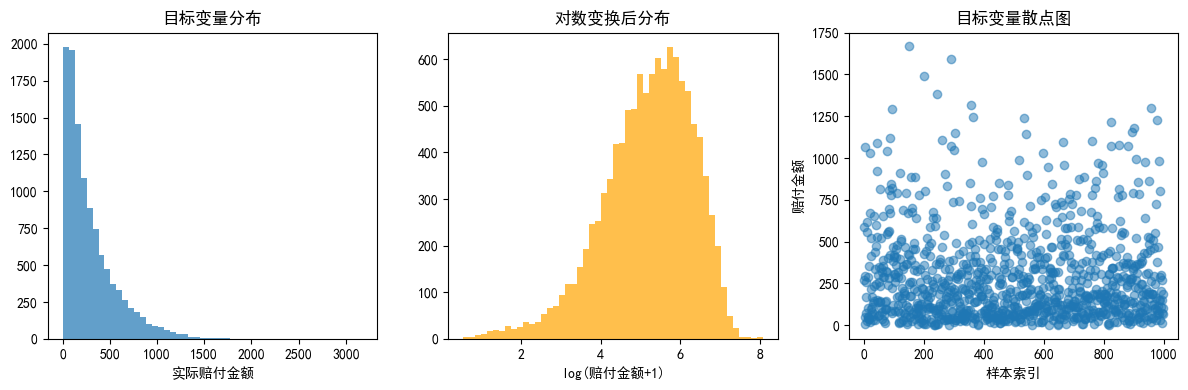


=== 特征工程 ===
基础数据清洗...
创建关键特征...
处理分类变量...
特征工程后数据形状: (11167, 68)
数据分割...
目标变量统计: 均值=292.24, 标准差=281.78, 最小值=0.74, 最大值=3171.47
分割后训练集形状: (8933, 67)
分割后测试集形状: (2234, 67)
训练集目标变量统计:
count    8933.000000
mean      293.254187
std       281.697807
min         0.740000
25%        90.290000
50%       202.490000
75%       409.790000
max      3171.470000
Name: 实际赔付金额, dtype: float64

测试集目标变量统计:
count    2234.000000
mean      288.190201
std       282.135173
min         0.900000
25%        83.967500
50%       190.560000
75%       406.635000
max      2309.540000
Name: 实际赔付金额, dtype: float64
特征选择...
派生特征数量: 27
派生特征列表: ['索赔报价差', '索赔报价比', '赔付比例', '是否超赔', '保价金额_分桶', '索赔金额_分桶', '时效组合', '时效比值', '始发目的城市组合_编码', '生鲜服务等级', '保价金额_配送超时时长_乘积', '索赔金额_配送超时时长_乘积', '妥投到进线时长_配送超时时长_乘积', '保价金额_log', '保价金额_平方', '保价金额_平方根', '索赔金额_log', '索赔金额_平方', '索赔金额_平方根', '妥投到进线时长_log', '妥投到进线时长_平方', '妥投到进线时长_平方根', '配送超时时长_log', '配送超时时长_平方', '配送超时时长_平方根', '索赔金额_相对于中位数', '索赔金额_是否高于中位数']
使用特征数量: 34
使用的特征: ['索赔金额', '保价金额', '线路类型', '进

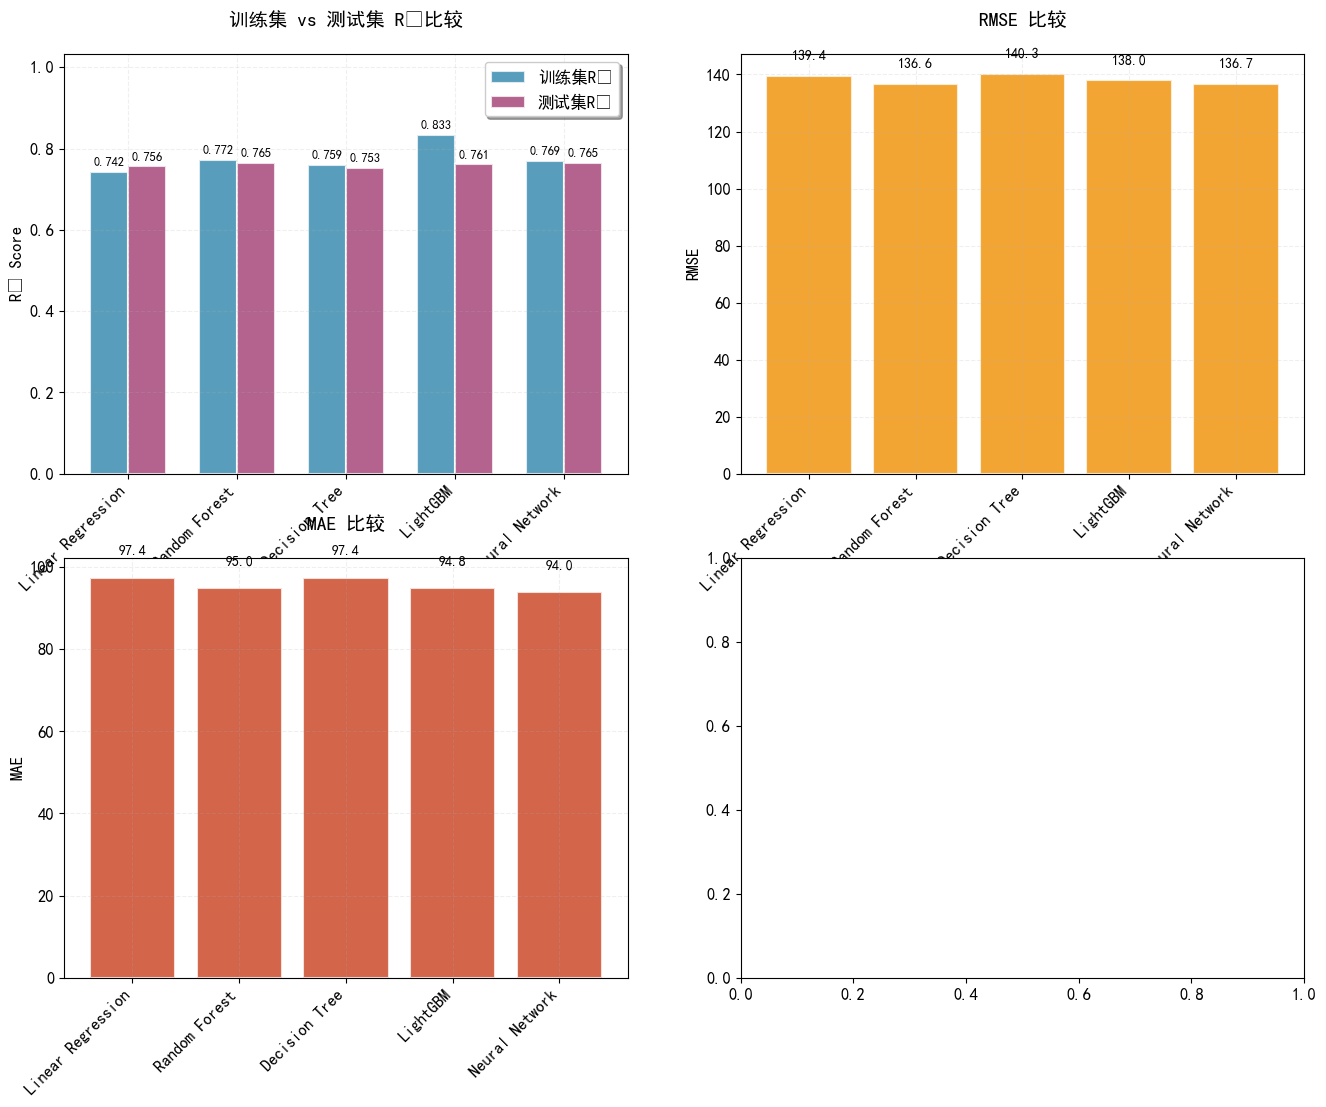

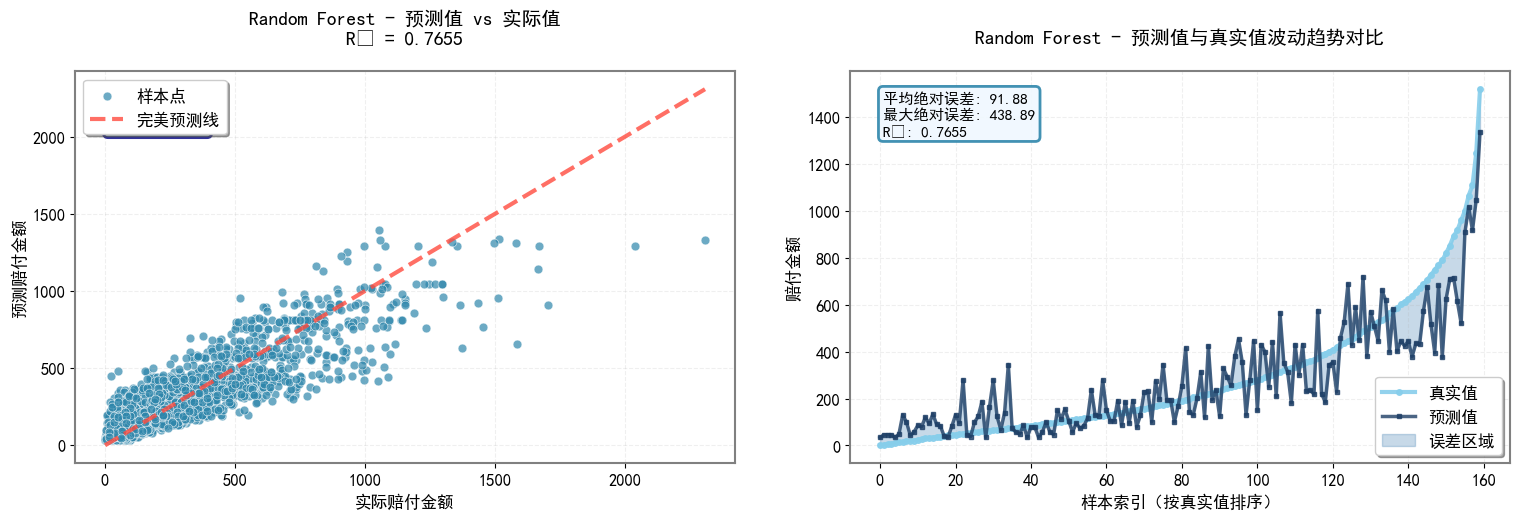


=== 特征重要性分析 (Top 10) ===

Random Forest 特征重要性:


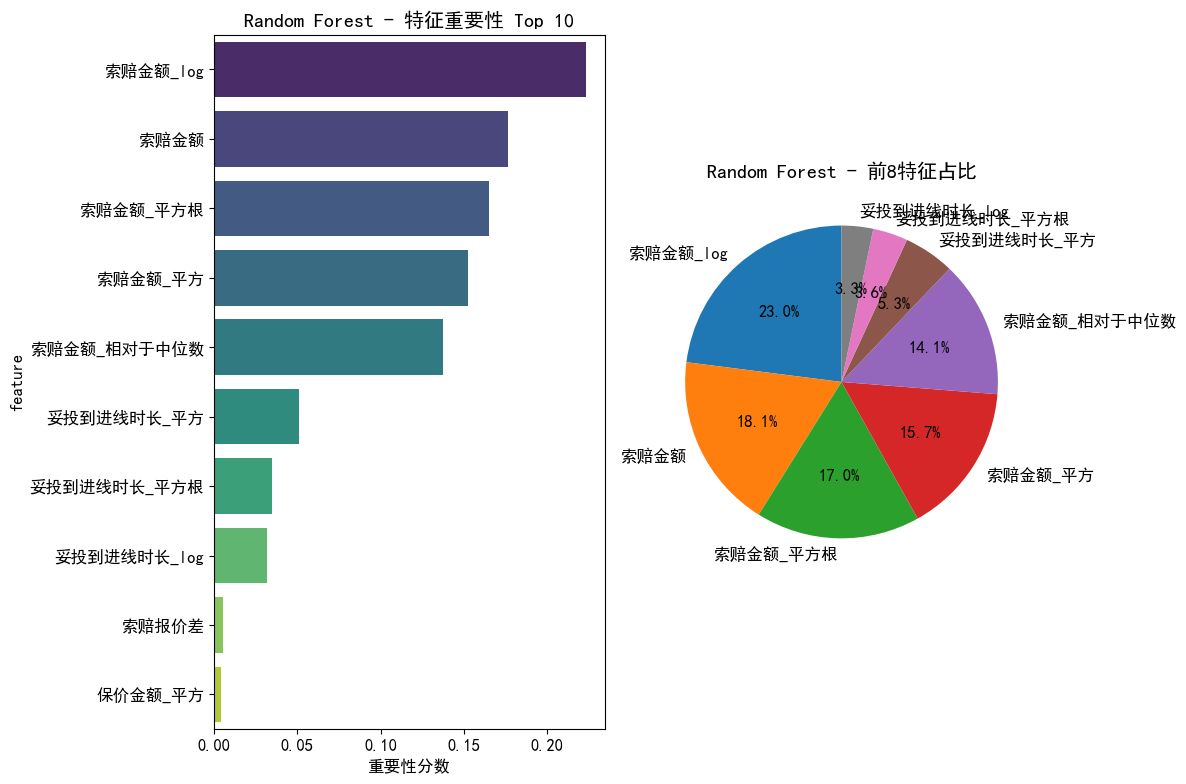

前10个重要特征:
        feature  importance
23     索赔金额_log    0.223351
0          索赔金额    0.176291
25     索赔金额_平方根    0.164929
24      索赔金额_平方    0.152120
32  索赔金额_相对于中位数    0.137277
27   妥投到进线时长_平方    0.051067
28  妥投到进线时长_平方根    0.035112
26  妥投到进线时长_log    0.031646
7         索赔报价差    0.005545
21      保价金额_平方    0.004003

特征相关性热力图:


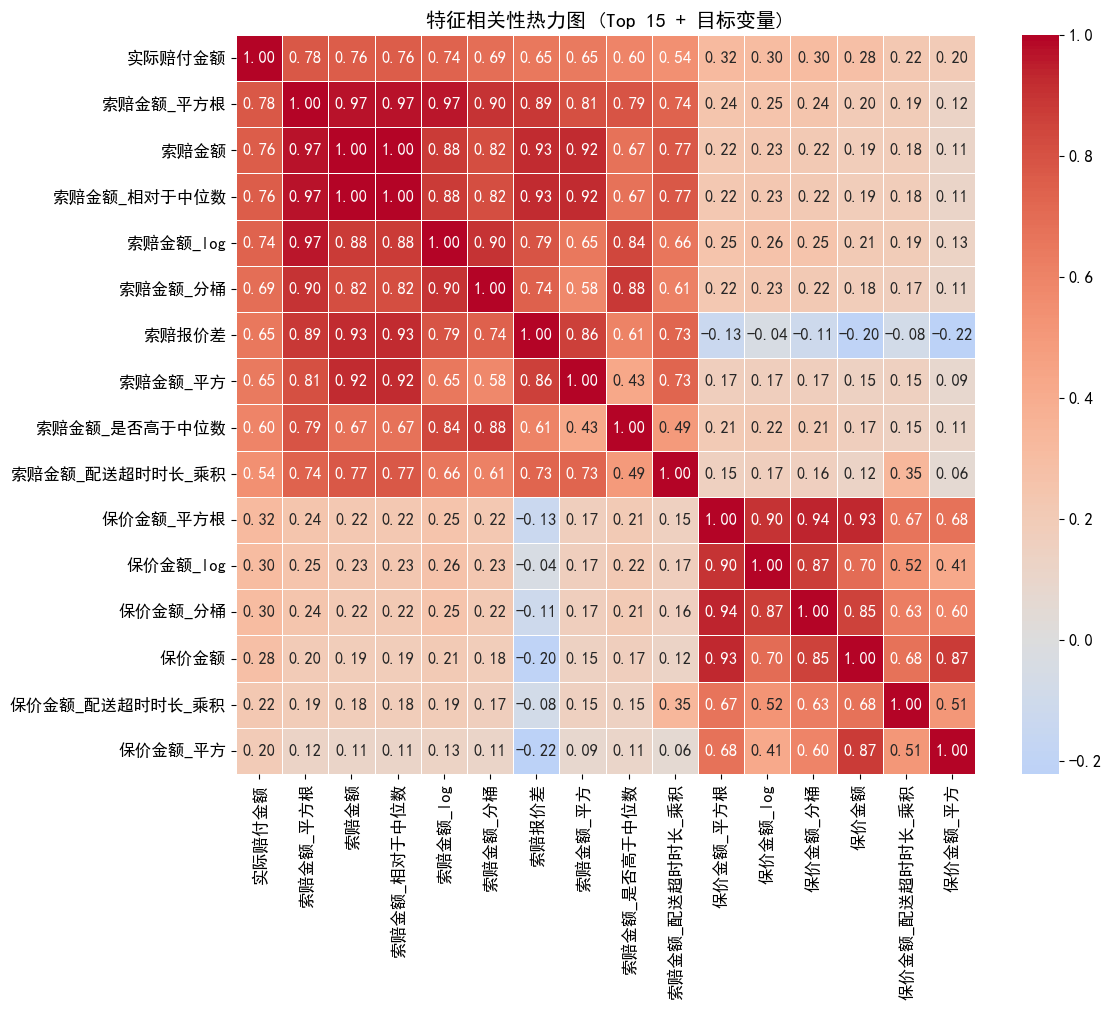

📊 模型性能详细比较:
                   Train_R2  Test_R2      MAE         MSE      RMSE      R2  \
Linear Regression    0.7417   0.7559  97.3905  19418.5400  139.3504  0.7559   
Random Forest        0.7718   0.7655  94.9552  18653.9741  136.5796  0.7655   
Decision Tree        0.7593   0.7527  97.4299  19678.1118  140.2787  0.7527   
LightGBM             0.8333   0.7608  94.7980  19035.2353  137.9682  0.7608   
Neural Network       0.7695   0.7651  94.0480  18685.7656  136.6959  0.7651   

                      MAPE  
Linear Regression  92.2074  
Random Forest      91.5636  
Decision Tree      92.4550  
LightGBM           87.7477  
Neural Network     84.8815  

🎯 R²分数详细比较:
                   Train_R2  Test_R2      R2
Linear Regression    0.7417   0.7559  0.7559
Random Forest        0.7718   0.7655  0.7655
Decision Tree        0.7593   0.7527  0.7527
LightGBM             0.8333   0.7608  0.7608
Neural Network       0.7695   0.7651  0.7651


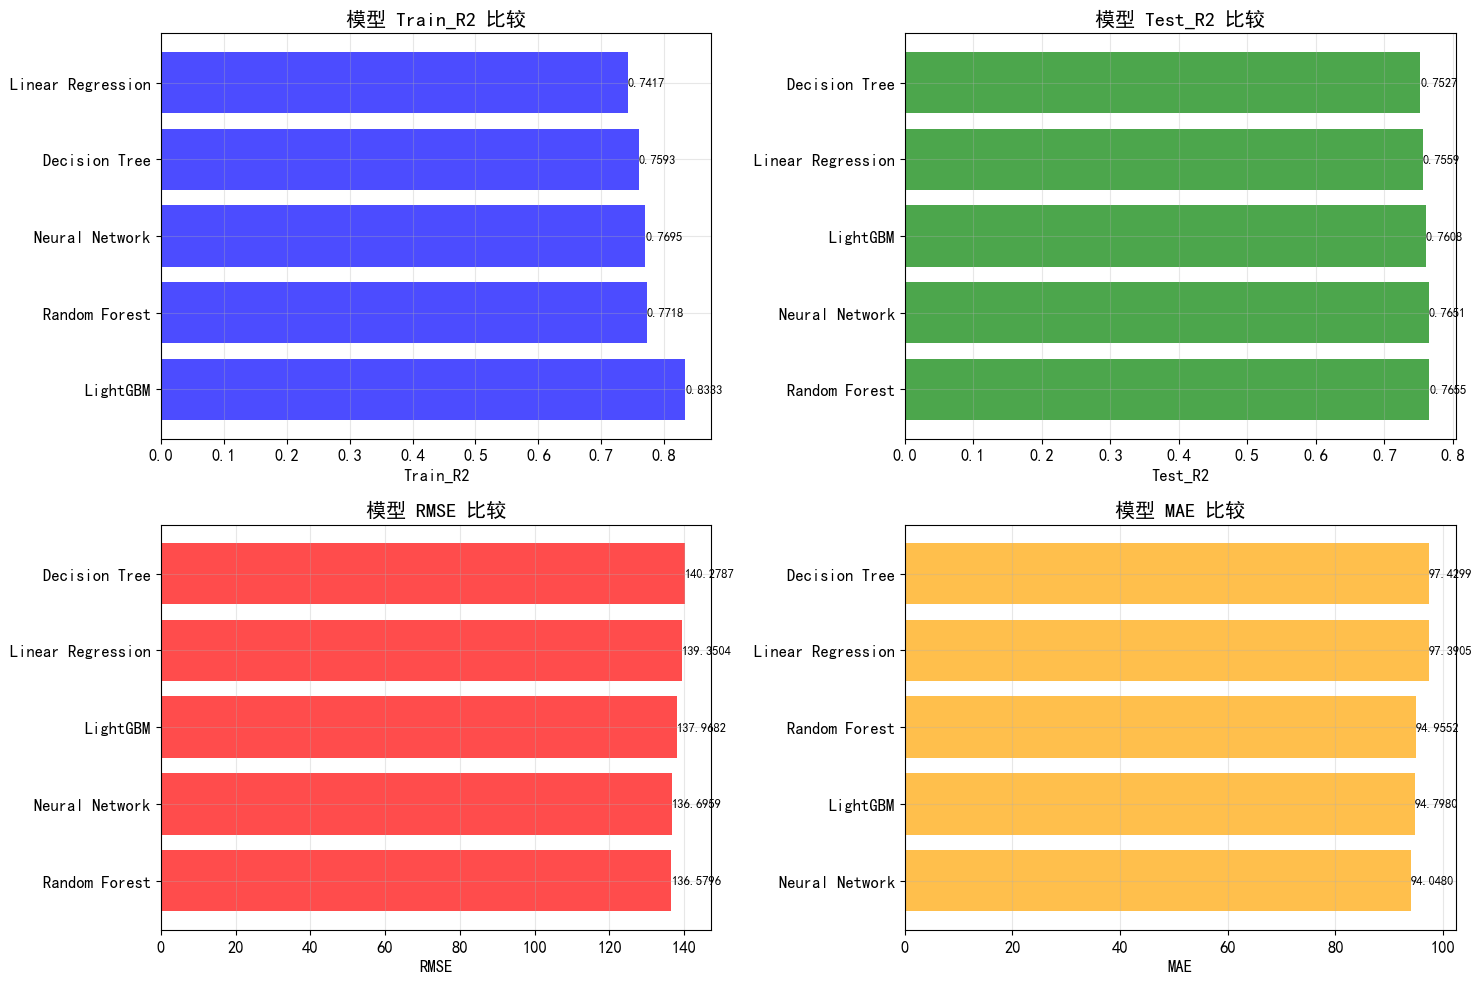

In [13]:
#Cell 13 创建预测器实例并执行完整流程
predictor = InsuranceClaimPredictor()
try:
    df = predictor.load_and_explore_data('预处理后的附件1.csv')
    correlations = predictor.data_quality_diagnosis()
    df_processed = predictor.advanced_feature_engineering()
    X_train, X_test, y_train, y_test = predictor.prepare_data()
    results = predictor.train_models()
    results_df = predictor.evaluate_models()
    
    # 显示特征重要性（如果有有效模型）
    valid_results = pd.DataFrame(results).T
    valid_results = valid_results[valid_results['R2'].notna()]
    if len(valid_results) > 0 and any(r2 > 0 for r2 in valid_results['R2']):
        predictor.show_feature_importance(top_n=10)
    
    # 设置全局预测器以便后续使用
    global_predictor = predictor
    
    # 显示模型性能比较
    get_model_performance_comparison(global_predictor)
    plot_model_comparison_chart(global_predictor)
    
except Exception as e:
    print(f"执行过程中出现错误: {e}")
    import traceback
    traceback.print_exc()

独立预测函数已定义完成！
使用方法: predict_new_insurance_claims(trained_predictor, '新数据文件路径', '输出文件名')
=== 开始预测新文件实际赔付金额 ===
1. 加载新数据: 预处理后的附件2.csv
   新数据形状: (2792, 40)
   新数据列名: ['运单号', '线路类型', '是否c2c', '是否生鲜妥投及时', '保价金额', '始发城市', '目的城市', '寄件人id', '收件人id', '寄件是否内部', '配送超时时长', '异常原因', '进线渠道', '妥投到进线时长', '索赔金额', '商品类型', '新旧程度', '寄件B/C', '进线人身份', '始发网点发单量', '始发网点万单理赔率', '始发网点赔付比例', '目的网点发单量', '目的网点万单理赔率', '目的网点赔付比例', '异常原因_编码', '进线渠道_编码', '商品类型_编码', '进线人身份_编码', '妥投到进线时长_分桶', '是否生鲜商品', '生鲜妥投组合类别_编码', '始发城市_风险特征', '目的城市_风险特征', '寄件人_风险特征', '收件人_风险特征', '始发城市_风险标注均值', '目的城市_风险标注均值', '寄件人_风险标注均值', '收件人_风险标注均值']
2. 应用特征工程...
   特征工程后数据形状: (2792, 71)
3. 特征选择...
   使用特征数量: 34
   前10个特征: ['索赔金额', '保价金额', '线路类型', '进线渠道_编码', '商品类型_编码', '异常原因_编码', '进线人身份_编码', '索赔报价差', '索赔报价比', '赔付比例']
   预测数据形状: (2792, 34)
   预测数据基本信息:
     数值范围: [-176303708000000.00, 986049000000000000.00]
     缺失值数量: 0
4. 数据标准化...
   标准化完成
   标准化后数值范围: [-7.77, 122.35]
5. 选择最佳模型...
   使用模型: Random Forest
   模型性能 - 测试集R²: 0.7655, RMSE: 136.58
6. 进行预

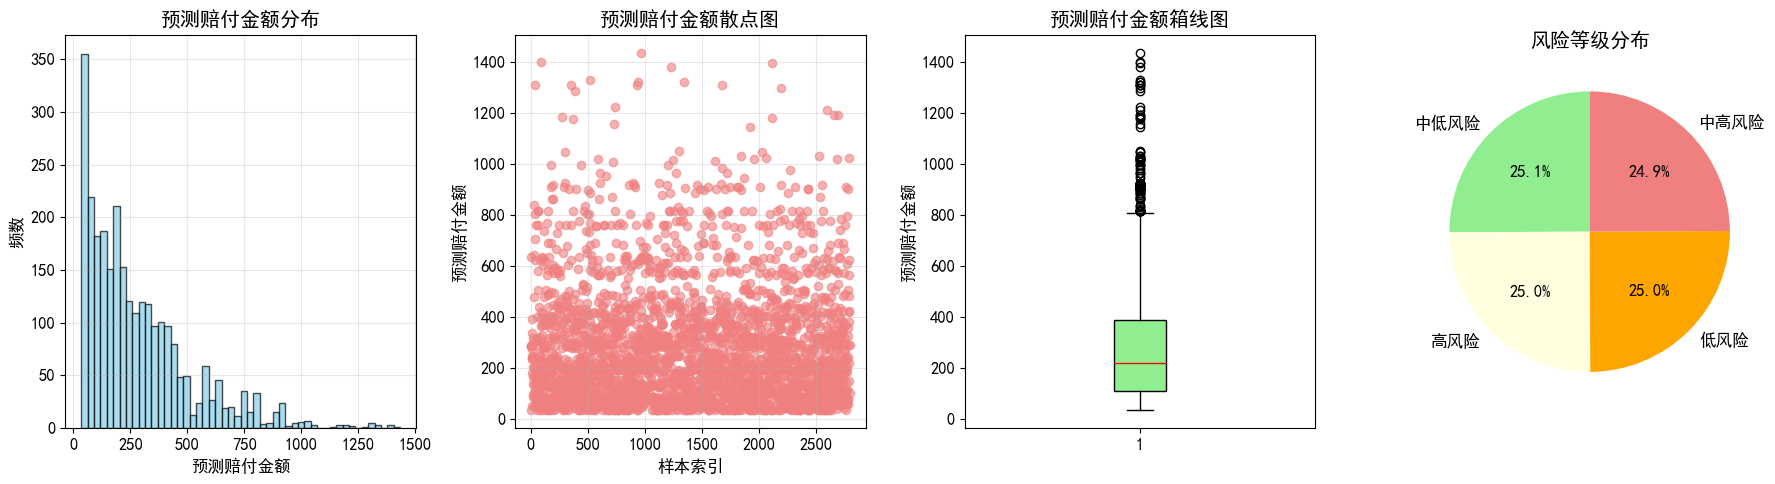

8. 保存预测结果...
   预测结果已保存到: 实际赔付金额预测结果.csv

预测结果前5行:
   运单号  线路类型      预测赔付金额  风险等级
0    1     2  284.050289  中高风险
1    2     2  286.312884  中高风险
2    3     2  633.199286   高风险
3    4     2  286.312884  中高风险
4    5     5   34.763496   低风险

=== 预测完成 ===
共处理 2792 条数据
预测赔付金额范围: 34.20 - 1433.16
平均预测赔付金额: 284.89


In [14]:
# Cell 14: 独立预测新文件实际赔付金额（处理无目标变量情况）
def predict_new_insurance_claims(trained_predictor, new_data_file_path, output_file='实际赔付金额预测结果.csv'):
    
    print("=== 开始预测新文件实际赔付金额 ===")
    
    # 检查预测器是否已训练
    if not hasattr(trained_predictor, 'models') or not trained_predictor.models:
        print("错误: 预测器尚未训练，请先运行模型训练")
        return None
    
    if not hasattr(trained_predictor, 'selected_features') or not trained_predictor.selected_features:
        print("错误: 未找到特征选择信息")
        return None
    
    # 1. 加载新数据
    print(f"1. 加载新数据: {new_data_file_path}")
    try:
        new_df = pd.read_csv(new_data_file_path)
        print(f"   新数据形状: {new_df.shape}")
        print(f"   新数据列名: {list(new_df.columns)}")
        
        # 检查新数据是否包含实际赔付金额列
        if '实际赔付金额' in new_df.columns:
            print("   注意: 新数据包含'实际赔付金额'列，但我们将忽略它并进行预测")
            # 可以选择移除该列或者保留但不使用
            # new_df = new_df.drop('实际赔付金额', axis=1)
            
    except Exception as e:
        print(f"   加载数据失败: {e}")
        return None
    
    # 2. 应用特征工程（专门处理无目标变量的情况）
    print("2. 应用特征工程...")
    new_df_processed = _apply_feature_engineering_for_prediction(new_df)
    
    # 3. 特征选择
    print("3. 特征选择...")
    available_features = [f for f in trained_predictor.selected_features if f in new_df_processed.columns]
   
    
    print(f"   使用特征数量: {len(available_features)}")
    print(f"   前10个特征: {available_features[:10]}")
    
    # 4. 准备预测数据
    X_new = new_df_processed[available_features]
    
    # 检查数据质量
    print(f"   预测数据形状: {X_new.shape}")
    print(f"   预测数据基本信息:")
    print(f"     数值范围: [{X_new.min().min():.2f}, {X_new.max().max():.2f}]")
    print(f"     缺失值数量: {X_new.isnull().sum().sum()}")
    
    # 5. 数据标准化
    print("4. 数据标准化...")
    try:
        X_new_scaled = trained_predictor.scaler.transform(X_new)
        print("   标准化完成")
        print(f"   标准化后数值范围: [{X_new_scaled.min():.2f}, {X_new_scaled.max():.2f}]")
    except Exception as e:
        print(f"   标准化失败: {e}")
        return None
    
    # 6. 选择最佳模型
    print("5. 选择最佳模型...")
    valid_models = {}
    for name, result in trained_predictor.results.items():
        if result is not None and not np.isnan(result.get('Test_R2', np.nan)):
            valid_models[name] = result
    
    if not valid_models:
        print("   没有有效的模型可用于预测")
        return None
    
    best_model_name = max(valid_models.items(), key=lambda x: x[1]['Test_R2'])[0]
    best_model = trained_predictor.models[best_model_name]
    best_r2 = trained_predictor.results[best_model_name]['Test_R2']
    best_rmse = trained_predictor.results[best_model_name].get('RMSE', 0)
    
    print(f"   使用模型: {best_model_name}")
    print(f"   模型性能 - 测试集R²: {best_r2:.4f}, RMSE: {best_rmse:.2f}")
    
    # 7. 进行预测
    print("6. 进行预测...")
    try:
        predictions = best_model.predict(X_new_scaled)
        print(f"   预测完成，共预测{len(predictions)}条数据")
    except Exception as e:
        print(f"   预测失败: {e}")
        return None
    
    # 8. 创建结果DataFrame
    result_df = new_df.copy()
    result_df['预测赔付金额'] = predictions
    
    # 添加预测置信区间（基于模型在测试集上的RMSE）
    if best_rmse > 0:
        result_df['预测置信区间_下限'] = np.maximum(0, predictions - best_rmse)  # 赔付金额不能为负
        result_df['预测置信区间_上限'] = predictions + best_rmse
        result_df['预测误差范围'] = best_rmse
    
    # 添加风险等级分类
    percentiles = np.percentile(predictions, [25, 50, 75, 90])
    def classify_risk(amount):
        if amount <= percentiles[0]:
            return '低风险'
        elif amount <= percentiles[1]:
            return '中低风险'
        elif amount <= percentiles[2]:
            return '中高风险'
        else:
            return '高风险'
    
    result_df['风险等级'] = result_df['预测赔付金额'].apply(classify_risk)
    
    # 9. 显示预测结果统计
    print("\n=== 预测结果统计 ===")
    print(f"预测赔付金额统计:")
    print(f"  均值: {predictions.mean():.2f}")
    print(f"  标准差: {predictions.std():.2f}")
    print(f"  最小值: {predictions.min():.2f}")
    print(f"  25%分位数: {np.percentile(predictions, 25):.2f}")
    print(f"  中位数: {np.median(predictions):.2f}")
    print(f"  75%分位数: {np.percentile(predictions, 75):.2f}")
    print(f"  最大值: {predictions.max():.2f}")
    
    print(f"\n风险等级分布:")
    risk_counts = result_df['风险等级'].value_counts()
    for risk, count in risk_counts.items():
        percentage = (count / len(result_df)) * 100
        print(f"  {risk}: {count}条 ({percentage:.1f}%)")
    
    # 10. 可视化预测结果
    print("\n7. 生成预测结果可视化...")
    plt.figure(figsize=(18, 5))
    
    # 预测值分布
    plt.subplot(1, 4, 1)
    plt.hist(predictions, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('预测赔付金额分布')
    plt.xlabel('预测赔付金额')
    plt.ylabel('频数')
    plt.grid(True, alpha=0.3)
    
    # 预测值散点图
    plt.subplot(1, 4, 2)
    plt.scatter(range(len(predictions)), predictions, alpha=0.6, color='lightcoral')
    plt.title('预测赔付金额散点图')
    plt.xlabel('样本索引')
    plt.ylabel('预测赔付金额')
    plt.grid(True, alpha=0.3)
    
    # 预测值箱线图
    plt.subplot(1, 4, 3)
    plt.boxplot(predictions, patch_artist=True, 
                boxprops=dict(facecolor='lightgreen', color='black'),
                medianprops=dict(color='red'))
    plt.title('预测赔付金额箱线图')
    plt.ylabel('预测赔付金额')
    
    # 风险等级分布
    plt.subplot(1, 4, 4)
    risk_counts = result_df['风险等级'].value_counts()
    colors = ['lightgreen', 'lightyellow', 'orange', 'lightcoral']
    plt.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
    plt.title('风险等级分布')
    
    plt.tight_layout()
    plt.show()
    
    # 11. 保存结果
    print("8. 保存预测结果...")
    try:
        # 选择要保存的列（原始数据 + 预测结果）
        output_columns = list(new_df.columns) + ['预测赔付金额', '风险等级']
        if '预测置信区间_下限' in result_df.columns:
            output_columns.extend(['预测置信区间_下限', '预测置信区间_上限', '预测误差范围'])
        
        result_df[output_columns].to_csv(output_file, index=False, encoding='utf-8-sig')
        print(f"   预测结果已保存到: {output_file}")
        
        # 显示前几行结果
        print(f"\n预测结果前5行:")
        display_columns = ['预测赔付金额', '风险等级']
        if len(new_df.columns) > 0:
            display_columns = list(new_df.columns)[:2] + display_columns  # 显示前2个原始列
        
        print(result_df[display_columns].head())
        
    except Exception as e:
        print(f"   保存结果失败: {e}")
    
    print(f"\n=== 预测完成 ===")
    print(f"共处理 {len(result_df)} 条数据")
    print(f"预测赔付金额范围: {predictions.min():.2f} - {predictions.max():.2f}")
    print(f"平均预测赔付金额: {predictions.mean():.2f}")
    
    return result_df

def _apply_feature_engineering_for_prediction(df):
    """
    专门用于预测的特征工程函数
    处理没有目标变量的情况
    """
    df_processed = df.copy()
    
    # 数值型特征的缺失值处理
    numerical_cols = df_processed.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if df_processed[col].isnull().sum() > 0:
            # 不处理'实际赔付金额'，因为新数据中没有这一列
            df_processed[col].fillna(df_processed[col].median(), inplace=True)
    
    # 关键特征创建（与训练时保持一致）
    if '索赔金额' in df_processed.columns and '保价金额' in df_processed.columns:
        df_processed['索赔报价差'] = df_processed['索赔金额'] - df_processed['保价金额']
        df_processed['索赔报价比'] = df_processed['索赔金额'] / (df_processed['保价金额'] + 1e-8)
        df_processed['赔付比例'] = df_processed['索赔金额'] / (df_processed['保价金额'] + 1e-8)
        df_processed['是否超赔'] = (df_processed['索赔金额'] > df_processed['保价金额']).astype(int)
    
    # 分桶特征
    for col_name, col in [('保价金额', '保价金额'), ('索赔金额', '索赔金额')]:
        if col in df_processed.columns and not df_processed[col].isna().all():
            df_processed[f'{col}_分桶'] = pd.cut(df_processed[col].fillna(df_processed[col].median()), 
                                         bins=[0, 100, 500, 1000, 5000, float('inf')], 
                                         labels=[0, 1, 2, 3, 4])
            df_processed[f'{col}_分桶'] = df_processed[f'{col}_分桶'].cat.add_categories([-1]).fillna(-1).astype(int)
    
    # 时间特征组合
    if '妥投到进线时长' in df_processed.columns and '配送超时时长' in df_processed.columns:
        时效1 = df_processed['妥投到进线时长'].fillna(df_processed['妥投到进线时长'].median())
        时效2 = df_processed['配送超时时长'].fillna(df_processed['配送超时时长'].median())
        df_processed['时效组合'] = 时效1 * 时效2
        df_processed['时效比值'] = 时效1 / (时效2 + 1e-8)
    
    # 地域组合特征
    地域特征 = ['始发城市', '目的城市', '始发网点类别_target_encoded', '目的网点类别_target_encoded']
    存在的地域特征 = [col for col in 地域特征 if col in df_processed.columns]
    
    if len(存在的地域特征) >= 2:
        col1_data = df_processed[存在的地域特征[0]].fillna('未知').astype(str)
        col2_data = df_processed[存在的地域特征[1]].fillna('未知').astype(str)
        df_processed['始发目的城市组合'] = col1_data + '_' + col2_data
    
    # 对组合特征进行编码
    if '始发目的城市组合' in df_processed.columns:
        le = LabelEncoder()
        try:
            df_processed['始发目的城市组合_编码'] = le.fit_transform(df_processed['始发目的城市组合'])
        except:
            # 如果编码失败，使用简单哈希
            df_processed['始发目的城市组合_编码'] = df_processed['始发目的城市组合'].apply(lambda x: hash(str(x)) % 10000)
    
    # 业务逻辑特征
    if '是否生鲜妥投及时' in df_processed.columns:
        df_processed['生鲜服务等级'] = df_processed['是否生鲜妥投及时'].fillna(0).copy()
    
    # 多特征交叉组合
    重要数值特征 = ['保价金额', '索赔金额', '妥投到进线时长', '配送超时时长']
    存在的数值特征 = [col for col in 重要数值特征 if col in df_processed.columns]
    
    # 创建特征间的乘积组合
    for i in range(len(存在的数值特征)):
        for j in range(i+1, len(存在的数值特征)):
            col1, col2 = 存在的数值特征[i], 存在的数值特征[j]
            data1 = df_processed[col1].fillna(df_processed[col1].median())
            data2 = df_processed[col2].fillna(df_processed[col2].median())
            df_processed[f'{col1}_{col2}_乘积'] = data1 * data2
    
    # 数学变换特征
    for col in 存在的数值特征:
        clean_data = df_processed[col].fillna(df_processed[col].median())
        df_processed[f'{col}_log'] = np.log1p(np.abs(clean_data))
        df_processed[f'{col}_平方'] = clean_data ** 2
        df_processed[f'{col}_平方根'] = np.sqrt(np.abs(clean_data))
    
    # 相对位置特征
    if '索赔金额' in df_processed.columns:
        索赔金额中位数 = df_processed['索赔金额'].median()
        clean_索赔金额 = df_processed['索赔金额'].fillna(索赔金额中位数)
        df_processed['索赔金额_相对于中位数'] = clean_索赔金额 - 索赔金额中位数
        df_processed['索赔金额_是否高于中位数'] = (clean_索赔金额 > 索赔金额中位数).astype(int)
    
    # 处理分类变量
    categorical_columns = [col for col in df_processed.columns 
                         if df_processed[col].dtype == 'object']
    
    for col in categorical_columns:
        if df_processed[col].nunique() <= 20:  
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    
    print(f"   特征工程后数据形状: {df_processed.shape}")
    
    return df_processed

print("独立预测函数已定义完成！")
print("使用方法: predict_new_insurance_claims(trained_predictor, '新数据文件路径', '输出文件名')")

# 使用示例（在训练完成后运行）
# 假设你已经训练好了predictor

# 预测新数据
result = predict_new_insurance_claims(
    trained_predictor=predictor,           # 已训练的预测器
    new_data_file_path='预处理后的附件2.csv',       # 新数据文件（没有实际赔付金额列）
    output_file='实际赔付金额预测结果.csv'         # 输出文件名
)